# Fruit Freshness Classification Using Deep Learning

This Colab project classifies fruit images into **6 classes**: Fresh/Rotten Apple, Fresh/Rotten Banana, and Fresh/Rotten Orange.

It uses a Kaggle dataset, a custom CNN, and **MobileNetV2 transfer learning**. The final section allows prediction on a new uploaded image.

### 1. GPU and environment check
This cell checks whether Google Colab has a GPU and imports the main libraries needed for the project.

In [42]:
import os
import shutil
import zipfile
import random
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus if gpus else "None")
if gpus:
    print(" GPU is available.")
else:
    print("GPU not detected. For faster training use Runtime → Change runtime type → T4 GPU.")

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 GPU is available.


### 2. Project configuration
This cell defines the Kaggle direct-download URL and all paths/settings used by the notebook. No Kaggle API key or `kaggle.json` is required.

In [43]:
KAGGLE_URL = "https://www.kaggle.com/api/v1/datasets/download/sriramr/fruits-fresh-and-rotten-for-classification"

ZIP_PATH = "/content/fruits-fresh-and-rotten.zip"
EXTRACT_PATH = "/content/fruit_dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.20

print("Dataset URL:", KAGGLE_URL)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Dataset URL: https://www.kaggle.com/api/v1/datasets/download/sriramr/fruits-fresh-and-rotten-for-classification
Image size: (224, 224)
Batch size: 32


### 3. Check available Colab disk space
The dataset is large, so this cell checks available storage before downloading.

In [44]:
total, used, free = shutil.disk_usage("/content")
print(f"Total space : {total / (1024**3):.2f} GB")
print(f"Used space  : {used / (1024**3):.2f} GB")
print(f"Free space  : {free / (1024**3):.2f} GB")

if free < 6 * 1024**3:
    print(" Less than 6 GB is free. A fresh extraction may need more space.")
else:
    print("Enough working space is available for the download/extraction.")

Total space : 112.64 GB
Used space  : 51.09 GB
Free space  : 61.53 GB
Enough working space is available for the download/extraction.


### 4. Download the Kaggle dataset directly
The dataset is downloaded with `wget`, so no Kaggle account configuration or API key is needed. An existing valid ZIP is reused.

In [45]:
def valid_zip(path):
    if not os.path.exists(path) or os.path.getsize(path) < 1024:
        return False
    try:
        with zipfile.ZipFile(path, "r") as z:
            return z.testzip() is None
    except zipfile.BadZipFile:
        return False

if valid_zip(ZIP_PATH):
    print(" A valid dataset ZIP already exists. Reusing it.")
else:
    if os.path.exists(ZIP_PATH):
        os.remove(ZIP_PATH)
        print("Removed an incomplete/invalid previous ZIP.")

    print("Downloading dataset... This can take several minutes.")
    result = subprocess.run(
        ["wget", "-O", ZIP_PATH, KAGGLE_URL],
        text=True
    )
    if result.returncode != 0 or not os.path.exists(ZIP_PATH):
        raise RuntimeError(" Dataset download failed.")

    if not valid_zip(ZIP_PATH):
        raise RuntimeError(
            "Download finished, but the ZIP is invalid/incomplete. "
            "Run this cell again to retry."
        )

zip_gb = os.path.getsize(ZIP_PATH) / (1024**3)
print(f" Valid ZIP downloaded: {zip_gb:.2f} GB")

 Valid ZIP downloaded: 3.58 GB


### 5. Inspect and safely extract the dataset
This cell verifies the ZIP and extracts it. The ZIP is **not deleted** until the expected train/test folders and class folders have been successfully found.

In [46]:
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    print("ZIP verified.")
    print("First entries:")
    for name in z.namelist()[:15]:
        print(" ", name)

os.makedirs(EXTRACT_PATH, exist_ok=True)

print("\nExtracting dataset...")
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_PATH)

print("Extraction completed.")

ZIP verified.
First entries:
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 4.59.44 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.01.15 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.01.22 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.01.41 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.02.43 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.03.40 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.04.16 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.04.24 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.05.34 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.05.41 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.07.18 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 at 5.07.26 PM.png
  dataset/dataset/test/freshapples/Screen Shot 2018-06-08 a

### 6. Automatically locate train and test folders
Dataset archives can contain an extra parent folder. This cell searches recursively instead of assuming a fixed path.

In [47]:
def find_named_dir(root, target_name):
    matches = []
    for current_root, dirs, files in os.walk(root):
        for d in dirs:
            if d.lower() == target_name.lower():
                matches.append(os.path.join(current_root, d))
    return sorted(matches, key=lambda p: (p.count(os.sep), p))

train_matches = find_named_dir(EXTRACT_PATH, "train")
test_matches = find_named_dir(EXTRACT_PATH, "test")

if not train_matches:
    raise FileNotFoundError("Could not find a train directory after extraction.")
if not test_matches:
    raise FileNotFoundError("Could not find a test directory after extraction.")

train_dir = train_matches[0]
test_dir = test_matches[0]

print("Train directory:", train_dir)
print("Test directory :", test_dir)

def get_class_dirs(folder):
    return sorted([
        d for d in os.listdir(folder)
        if os.path.isdir(os.path.join(folder, d))
    ])

train_classes = get_class_dirs(train_dir)
test_classes = get_class_dirs(test_dir)

print("\nTrain classes:", train_classes)
print("Test classes :", test_classes)

if len(train_classes) != 6:
    raise ValueError(f"Expected 6 training classes, found {len(train_classes)}: {train_classes}")

if set(train_classes) != set(test_classes):
    raise ValueError("Train and test class folders do not match.")

print("Dataset structure verified.")

Train directory: /content/fruit_dataset/dataset/train
Test directory : /content/fruit_dataset/dataset/test

Train classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Test classes : ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Dataset structure verified.


### 7. Remove the ZIP only after successful verification
The ZIP is deleted now to save disk space. If extraction/verification had failed, this cell would never be reached successfully.

In [48]:
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)
    print("ZIP deleted after successful extraction.")
else:
    print("ZIP already removed.")

ZIP deleted after successful extraction.


### 8. Count images in every class
This cell counts the available training and test images and creates a class-distribution table.

In [49]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def count_images(folder):
    return sum(
        1 for f in os.listdir(folder)
        if f.lower().endswith(IMAGE_EXTENSIONS)
    )

rows = []
for cls in train_classes:
    rows.append({
        "Class": cls,
        "Train": count_images(os.path.join(train_dir, cls)),
        "Test": count_images(os.path.join(test_dir, cls))
    })

distribution_df = pd.DataFrame(rows)
distribution_df["Total"] = distribution_df["Train"] + distribution_df["Test"]

display(distribution_df)

print("Total training images:", distribution_df["Train"].sum())
print("Total test images    :", distribution_df["Test"].sum())

,Class,Train,Test,Total
0,freshapples,1693,395,2088
1,freshbanana,1581,381,1962
2,freshoranges,1466,388,1854
3,rottenapples,2342,601,2943
4,rottenbanana,2224,530,2754
5,rottenoranges,1595,403,1998


Total training images: 10901
Total test images    : 2698


### 9. Visualize class distribution
The bar chart helps check whether the dataset contains a reasonable number of images in each class.

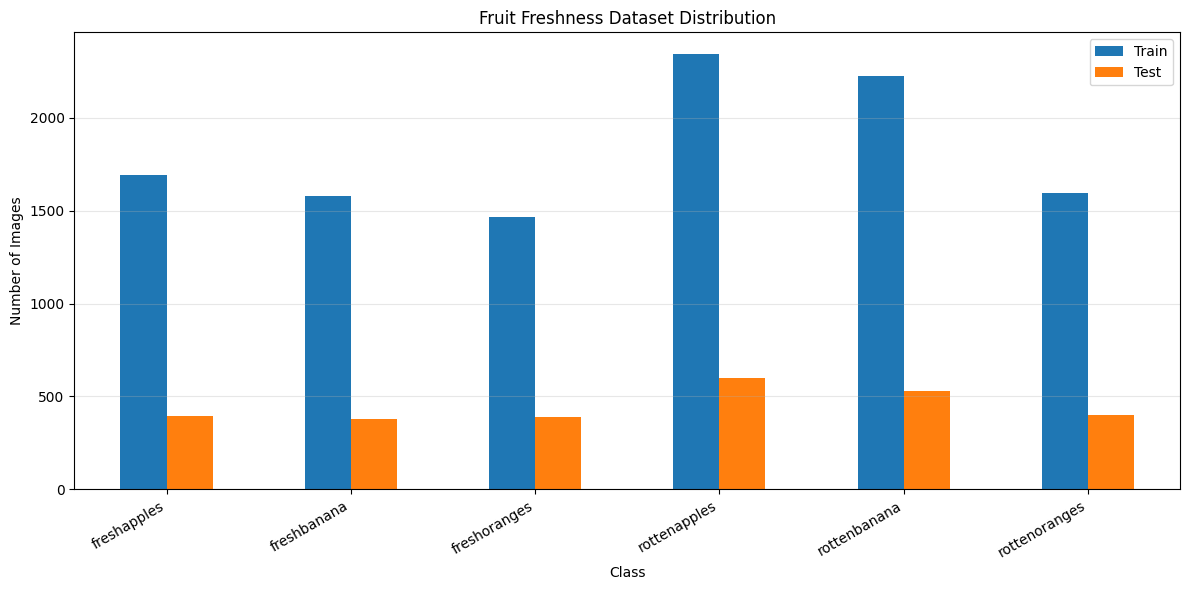

In [50]:
plot_df = distribution_df.set_index("Class")[["Train", "Test"]]
ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Fruit Freshness Dataset Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 10. Display sample images
This cell displays one random training image from each of the six classes so the dataset can be visually inspected.

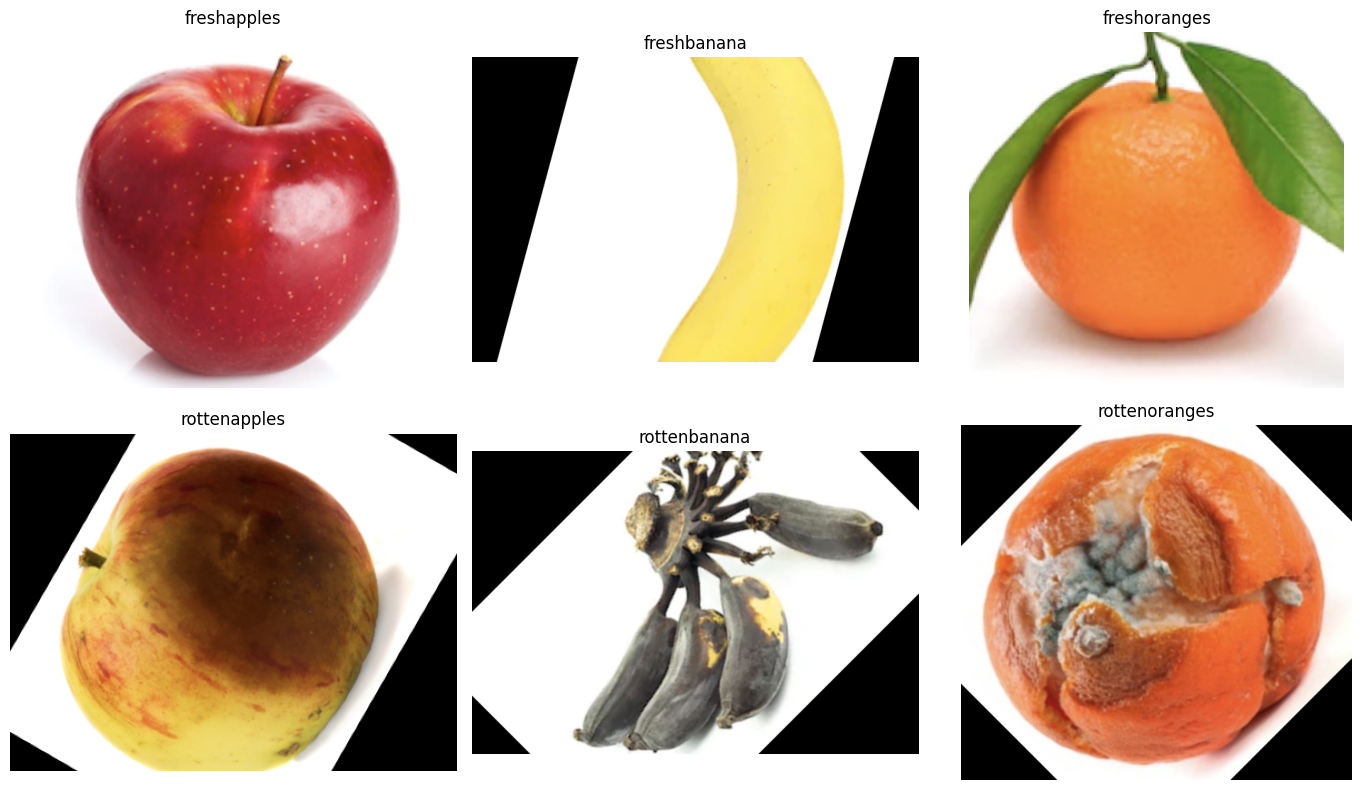

In [51]:
plt.figure(figsize=(14, 8))

for i, cls in enumerate(train_classes):
    folder = os.path.join(train_dir, cls)
    files = [f for f in os.listdir(folder) if f.lower().endswith(IMAGE_EXTENSIONS)]
    image_path = os.path.join(folder, random.choice(files))

    image = Image.open(image_path).convert("RGB")

    ax = plt.subplot(2, 3, i + 1)
    ax.imshow(image)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 11. Load training, validation and test datasets
The original test set is kept completely separate. Only the training folder is split into **80% training and 20% validation**.

In [52]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)
print("Number of classes:", NUM_CLASSES)

if NUM_CLASSES != 6:
    raise ValueError("This project expects exactly 6 classes.")

Found 10901 files belonging to 6 classes.
Using 8721 files for training.
Found 10901 files belonging to 6 classes.
Using 2180 files for validation.
Found 2698 files belonging to 6 classes.
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Number of classes: 6


### 12. Optimize the input pipeline
`prefetch` allows data loading and model training to overlap, which improves training efficiency without caching the entire large dataset in RAM.

In [53]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Dataset pipelines optimized.")

Dataset pipelines optimized.


### 13. Data augmentation
Random flips, rotations, zoom and contrast changes help the model learn features that are robust to small changes in fruit images.

In [54]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

print(" Data augmentation pipeline created.")

 Data augmentation pipeline created.


### 14. Preview augmented images
This cell shows examples after augmentation so the effect of the preprocessing can be checked.

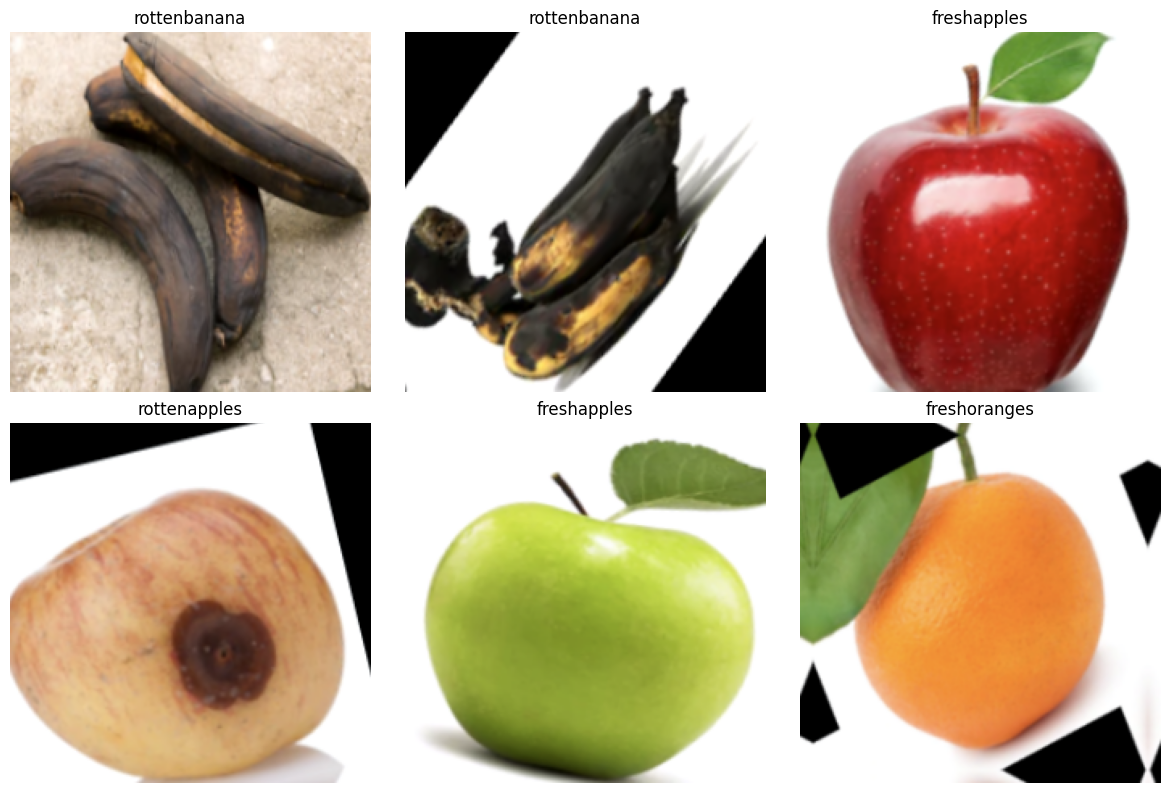

In [55]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(12, 8))
    for i in range(6):
        augmented = data_augmentation(images[i:i+1], training=True)[0]
        ax = plt.subplot(2, 3, i + 1)
        ax.imshow(tf.cast(augmented, tf.uint8))
        ax.set_title(class_names[int(labels[i])])
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    break

### 15. Build the custom CNN
This model learns fruit and freshness features directly from the images using convolution, pooling, global average pooling and dropout layers.

In [56]:
cnn_model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.40),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,006 (1.62 MB)

 Trainable params: 423,046 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

### 16. Train the custom CNN
The CNN is trained with early stopping and best-weight restoration to reduce unnecessary training and overfitting.

In [57]:
cnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=cnn_callbacks
)

Epoch 1/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 50s 167ms/step - accuracy: 0.7978 - loss: 0.5935 - val_accuracy: 0.4197 - val_loss: 2.2553
Epoch 2/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 82s 168ms/step - accuracy: 0.8559 - loss: 0.3959 - val_accuracy: 0.8289 - val_loss: 0.4551
Epoch 3/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 45s 164ms/step - accuracy: 0.8885 - loss: 0.3202 - val_accuracy: 0.8537 - val_loss: 0.4774
Epoch 4/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.8934 - loss: 0.3059 - val_accuracy: 0.8390 - val_loss: 0.4798


### 17. Plot CNN accuracy and loss
These graphs show whether the CNN is learning and whether training and validation performance remain consistent.

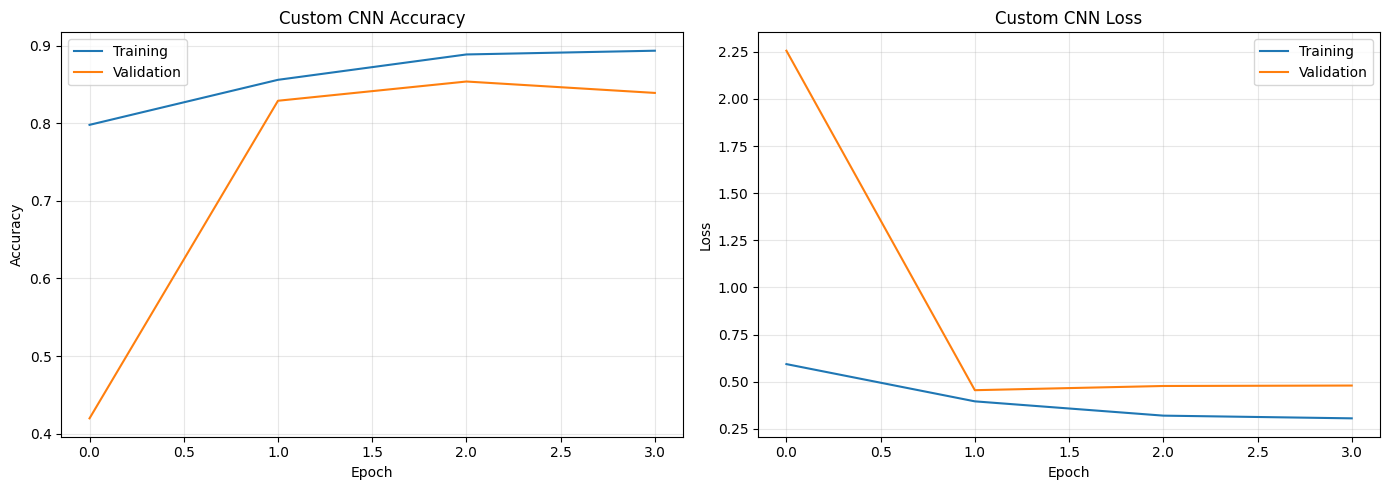

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history.history["accuracy"], label="Training")
axes[0].plot(cnn_history.history["val_accuracy"], label="Validation")
axes[0].set_title("Custom CNN Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(cnn_history.history["loss"], label="Training")
axes[1].plot(cnn_history.history["val_loss"], label="Validation")
axes[1].set_title("Custom CNN Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 18. Evaluate the custom CNN
This cell measures the CNN's performance on the untouched test set.

In [59]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_ds, verbose=1)

print(f"Custom CNN Test Accuracy: {cnn_test_accuracy * 100:.2f}%")

85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - accuracy: 0.8391 - loss: 0.4297
Custom CNN Test Accuracy: 83.91%


### 19. Build MobileNetV2 transfer-learning model
MobileNetV2 is pretrained on ImageNet. Its convolutional base is initially frozen, while a new six-class classifier is trained for this fruit dataset.

In [60]:
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

mobilenet_model = keras.Model(inputs, outputs)

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mobilenet_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 20. Train MobileNetV2 classifier
Only the new classification head is trained first. This provides a stable starting point before fine-tuning the pretrained feature extractor.

In [61]:
mobilenet_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

mobilenet_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=mobilenet_callbacks
)

Epoch 1/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.5683 - loss: 1.1413 - val_accuracy: 0.8628 - val_loss: 0.5487
Epoch 2/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 36s 132ms/step - accuracy: 0.8588 - loss: 0.4839 - val_accuracy: 0.9229 - val_loss: 0.3156
Epoch 3/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.9140 - loss: 0.3164 - val_accuracy: 0.9431 - val_loss: 0.2292
Epoch 4/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 38s 129ms/step - accuracy: 0.9305 - loss: 0.2488 - val_accuracy: 0.9528 - val_loss: 0.1826
Epoch 5/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 34s 126ms/step - accuracy: 0.9400 - loss: 0.2051 - val_accuracy: 0.9569 - val_loss: 0.1573
Epoch 6/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 35s 127ms/step - accuracy: 0.9492 - loss: 0.1752 - val_accuracy: 0.9628 - val_loss: 0.1351
Epoch 7/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 36s 131ms/step - accuracy: 0.9569 - loss: 0.1563 - val_accuracy: 0.9697 - val_loss: 0.1212
Epoch 8/8
273/273 ━━━━━━━━━━━━━━━━━━━━ 41s 130ms/step - accuracy: 0.9596 - loss: 0.1414 - 

### 21. Plot MobileNetV2 training curves
These plots show the training and validation accuracy/loss of the transfer-learning stage.

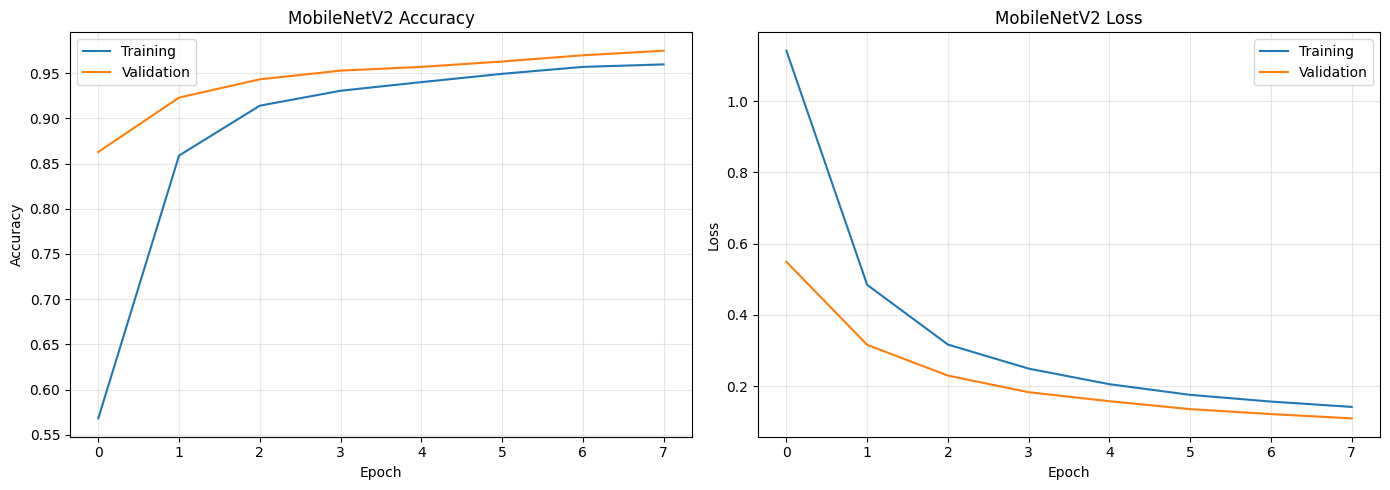

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mobilenet_history.history["accuracy"], label="Training")
axes[0].plot(mobilenet_history.history["val_accuracy"], label="Validation")
axes[0].set_title("MobileNetV2 Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(mobilenet_history.history["loss"], label="Training")
axes[1].plot(mobilenet_history.history["val_loss"], label="Validation")
axes[1].set_title("MobileNetV2 Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 22. Fine-tune MobileNetV2
The last approximately 30 layers are unfrozen and trained with a very small learning rate. This adapts the pretrained features to fruit freshness images.

In [63]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )
]

fine_history = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=fine_callbacks
)

trainable_layers = sum(layer.trainable for layer in base_model.layers)
print("Trainable MobileNetV2 layers:", trainable_layers)

Epoch 1/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 49s 143ms/step - accuracy: 0.8863 - loss: 0.3293 - val_accuracy: 0.9665 - val_loss: 0.1068
Epoch 2/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 40s 148ms/step - accuracy: 0.9650 - loss: 0.1208 - val_accuracy: 0.9771 - val_loss: 0.0702
Epoch 3/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 38s 138ms/step - accuracy: 0.9786 - loss: 0.0814 - val_accuracy: 0.9830 - val_loss: 0.0504
Epoch 4/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 38s 140ms/step - accuracy: 0.9818 - loss: 0.0626 - val_accuracy: 0.9908 - val_loss: 0.0309
Epoch 5/5
273/273 ━━━━━━━━━━━━━━━━━━━━ 39s 141ms/step - accuracy: 0.9857 - loss: 0.0489 - val_accuracy: 0.9927 - val_loss: 0.0211
Trainable MobileNetV2 layers: 30


### 23. Evaluate the final fine-tuned model
The fine-tuned MobileNetV2 is evaluated on the untouched test set and will be used as the final prediction model.

In [64]:
final_test_loss, final_test_accuracy = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print(f"Final MobileNetV2 Test Accuracy: {final_test_accuracy * 100:.2f}%")

85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.9904 - loss: 0.0273
Final MobileNetV2 Test Accuracy: 99.04%


### 24. Compare the two models
This table compares the custom CNN with MobileNetV2 after fine-tuning.

,Model,Test Accuracy (%)
0,Custom CNN,83.914012
1,Fine-Tuned MobileNetV2,99.036324


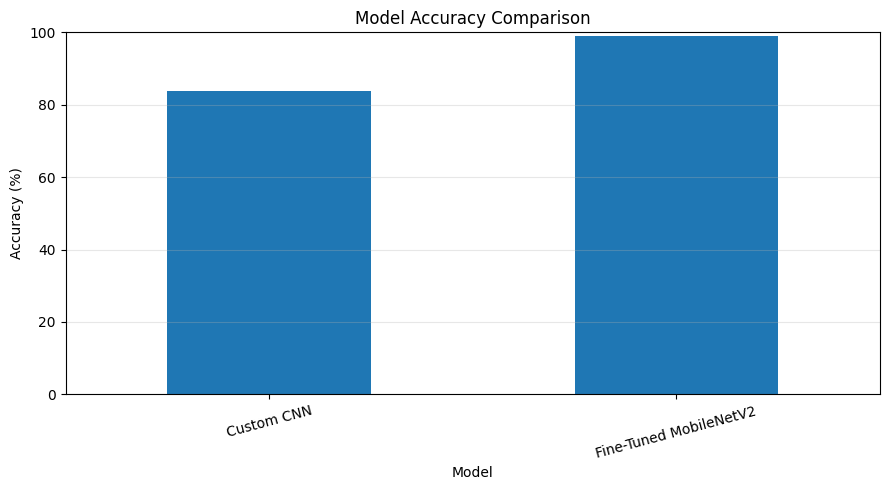

In [65]:
comparison = pd.DataFrame({
    "Model": ["Custom CNN", "Fine-Tuned MobileNetV2"],
    "Test Accuracy (%)": [
        cnn_test_accuracy * 100,
        final_test_accuracy * 100
    ]
})

display(comparison)

ax = comparison.plot(
    x="Model",
    y="Test Accuracy (%)",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)
ax.set_ylim(0, 100)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 25. Generate predictions for the complete test set
This cell obtains the predicted class and probabilities for every test image so detailed metrics can be calculated.

In [66]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probabilities = mobilenet_model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)
    y_prob.extend(probabilities)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Predictions generated:", len(y_pred))

Predictions generated: 2698


### 26. Calculate accuracy, precision, recall and F1-score
These metrics provide a more complete evaluation than accuracy alone.

In [67]:
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score (%)": [
        accuracy_score(y_true, y_pred) * 100,
        precision_score(y_true, y_pred, average="weighted", zero_division=0) * 100,
        recall_score(y_true, y_pred, average="weighted", zero_division=0) * 100,
        f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100
    ]
})

display(metrics_df)

,Metric,Score (%)
0,Accuracy,99.036323
1,Precision,99.057500
2,Recall,99.036323
3,F1 Score,99.039209


### 27. Classification report
The classification report gives precision, recall and F1-score separately for Fresh/Rotten Apple, Banana and Orange.

In [68]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

               precision    recall  f1-score   support

  freshapples       0.96      1.00      0.98       395
  freshbanana       1.00      1.00      1.00       381
 freshoranges       1.00      0.99      0.99       388
 rottenapples       0.99      0.98      0.98       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.99      0.99      0.99       403

     accuracy                           0.99      2698
    macro avg       0.99      0.99      0.99      2698
 weighted avg       0.99      0.99      0.99      2698



### 28. Confusion matrix
The confusion matrix shows which of the six fruit/freshness classes are predicted correctly and where the model makes mistakes.

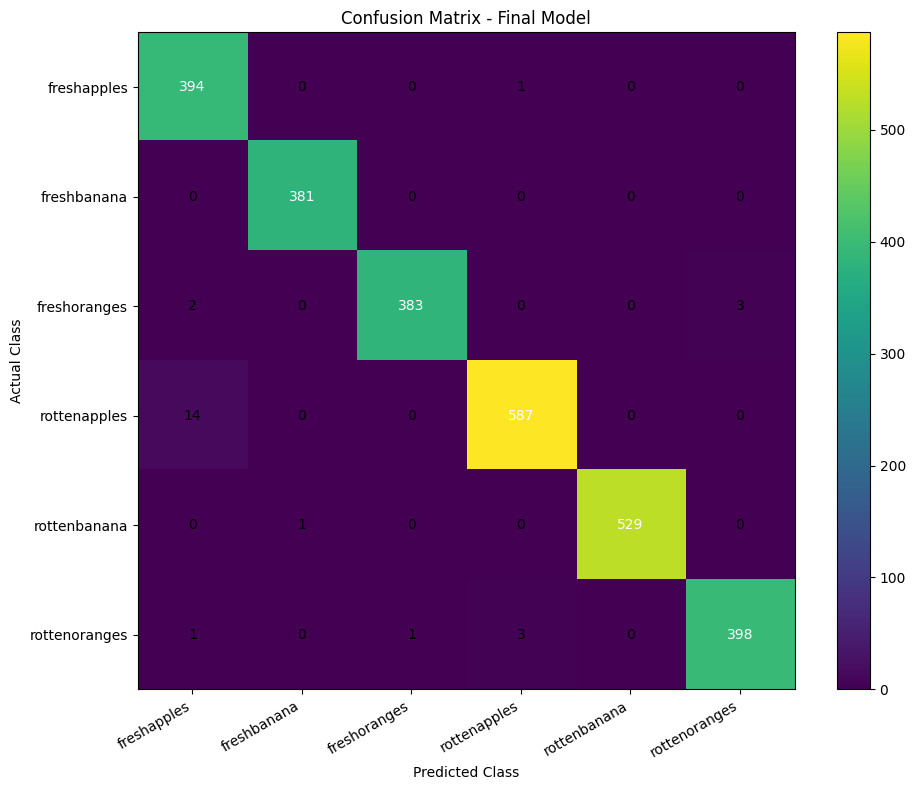

In [69]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm)

ax.set_title("Confusion Matrix - Final Model")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_yticklabels(class_names)

threshold = cm.max() / 2 if cm.size else 0
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(
            j, i, str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### 29. Save the final model
The fine-tuned MobileNetV2 model is saved in Keras format so it can be reused without retraining.

In [70]:
FINAL_MODEL_PATH = "/content/fruit_freshness_mobilenetv2.keras"

mobilenet_model.save(FINAL_MODEL_PATH)

print("Model saved to:", FINAL_MODEL_PATH)

Model saved to: /content/fruit_freshness_mobilenetv2.keras


### 30. Upload a new fruit image
Use Colab's upload dialog to provide an image of an apple, banana or orange. The model will classify both fruit type and freshness.

In [71]:
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise ValueError("No image was uploaded.")

uploaded_name = next(iter(uploaded))
print("Uploaded:", uploaded_name)

Saving download.jpg to download (1).jpg
Uploaded: download (1).jpg


### 31. Predict the uploaded image
The model first predicts one of the six complete classes. The predicted class is then converted into separate **fruit type**, **condition**, and **confidence** values.

In [72]:
image = tf.keras.utils.load_img(
    uploaded_name,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(image)
batch = np.expand_dims(image_array, axis=0)

probabilities = mobilenet_model.predict(batch, verbose=0)[0]
predicted_index = int(np.argmax(probabilities))
predicted_class = class_names[predicted_index]
confidence = float(probabilities[predicted_index] * 100)

def get_fruit_name(label):
    label_lower = label.lower()
    if "apple" in label_lower:
        return "Apple"
    if "banana" in label_lower:
        return "Banana"
    if "orange" in label_lower:
        return "Orange"
    return "Unknown"

def get_condition(label):
    return "Fresh" if "fresh" in label.lower() else "Rotten"

fruit = get_fruit_name(predicted_class)
condition = get_condition(predicted_class)

print("=" * 55)
print("FINAL PREDICTION")
print("=" * 55)
print("Class      :", predicted_class)
print("Fruit      :", fruit)
print("Condition  :", condition)
print(f"Confidence : {confidence:.2f}%")
print("=" * 55)

FINAL PREDICTION
Class      : rottenapples
Fruit      : Apple
Condition  : Rotten
Confidence : 99.74%


### 32. Display the final prediction on the image
This cell displays the uploaded image together with the predicted fruit, freshness condition and confidence.

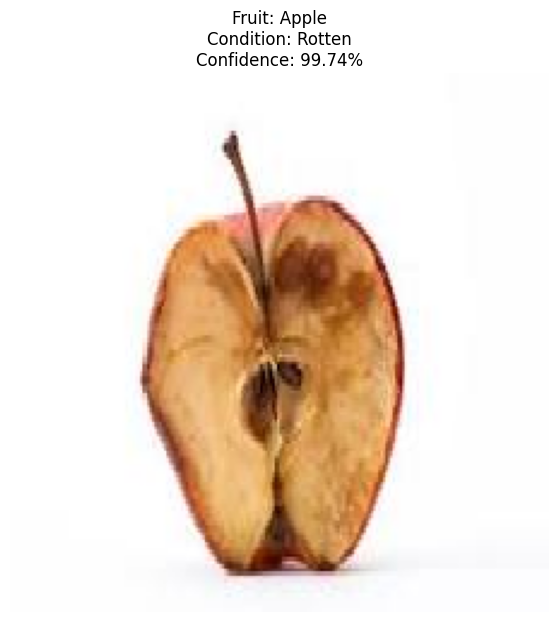

In [73]:
plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.title(
    f"Fruit: {fruit}\n"
    f"Condition: {condition}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.axis("off")
plt.show()

### 33. Show probabilities for all six classes
This table and graph show how strongly the model supports each possible class, not just the winning prediction.

,Class,Probability (%)
0,rottenapples,99.735947
1,rottenbanana,0.260213
2,freshapples,0.001657
3,freshbanana,0.001212
4,freshoranges,0.000531
5,rottenoranges,0.000443


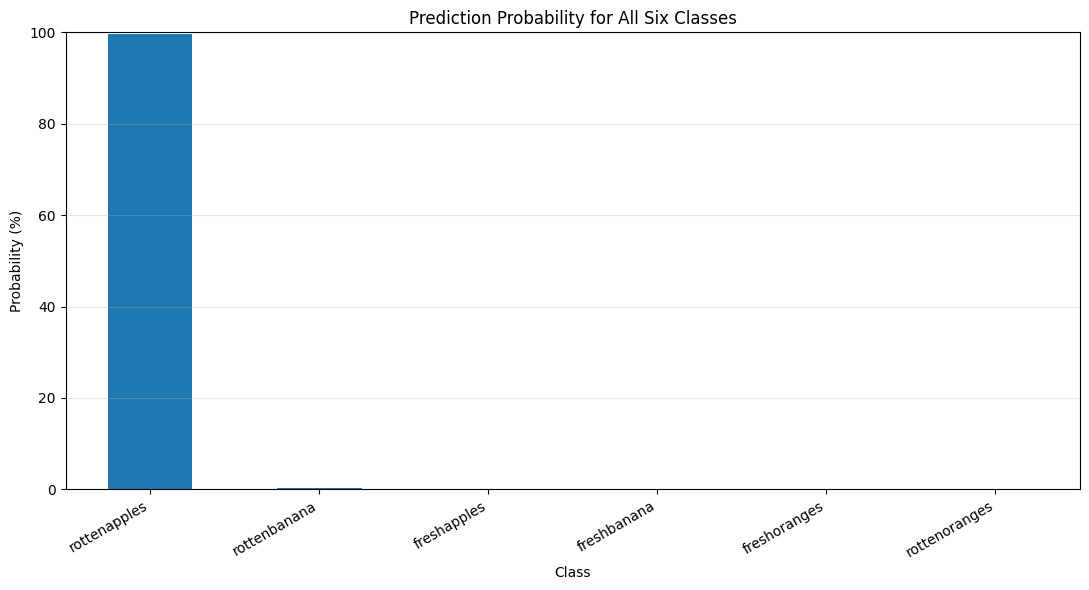

In [74]:
probability_df = pd.DataFrame({
    "Class": class_names,
    "Probability (%)": probabilities * 100
}).sort_values("Probability (%)", ascending=False).reset_index(drop=True)

display(probability_df)

ax = probability_df.plot(
    x="Class",
    y="Probability (%)",
    kind="bar",
    legend=False,
    figsize=(11, 6)
)
ax.set_ylim(0, 100)
ax.set_ylabel("Probability (%)")
ax.set_title("Prediction Probability for All Six Classes")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 34. Final project summary
This final cell prints the main result and confirms that the complete fruit freshness classification pipeline has finished successfully.

In [75]:
print("=" * 65)
print("FRUIT FRESHNESS CLASSIFICATION - PROJECT SUMMARY")
print("=" * 65)
print(f"Classes                : {NUM_CLASSES}")
print(f"Custom CNN accuracy    : {cnn_test_accuracy * 100:.2f}%")
print(f"Final MobileNetV2      : {final_test_accuracy * 100:.2f}%")
print(f"Uploaded image class   : {predicted_class}")
print(f"Predicted fruit        : {fruit}")
print(f"Predicted condition    : {condition}")
print(f"Prediction confidence  : {confidence:.2f}%")
print("=" * 65)


FRUIT FRESHNESS CLASSIFICATION - PROJECT SUMMARY
Classes                : 6
Custom CNN accuracy    : 83.91%
Final MobileNetV2      : 99.04%
Uploaded image class   : rottenapples
Predicted fruit        : Apple
Predicted condition    : Rotten
Prediction confidence  : 99.74%


## Conclusion

This project uses deep learning to classify fruit images into six categories: fresh or rotten apples, bananas and oranges. A custom CNN is compared with MobileNetV2 transfer learning. The final fine-tuned model is evaluated using accuracy, precision, recall, F1-score and a confusion matrix, and can classify a new uploaded fruit image with a confidence score.